# BVA Sequence Decomposition And Noise Simulation

Decompose a list of same-dimension unitaries into one continuous star-topology pulse sequence, then simulate the full pulse train with deterministic line-phase terms and shot-to-shot detuning noise.

The carried-frame convention is

    D_final @ U_pulses = U_N @ ... @ U_2 @ U_1

If `apply_final_frame` is enabled in the simulation section, the notebook appends that final diagonal frame exactly.


In [1]:
import numpy as np
from numpy.linalg import norm

from U_decomp import unitary_to_G_rotations

np.set_printoptions(precision=4, suppress=True)


In [2]:
def qudit_qft(d, inverse=False):
    if d < 2:
        raise ValueError("d must be at least 2")
    omega = np.exp((-2j if inverse else 2j) * np.pi / d)
    j = np.arange(d).reshape((d, 1))
    k = np.arange(d).reshape((1, d))
    return omega ** (j * k) / np.sqrt(d)


def haar_unitary(n, rng=None):
    rng = np.random.default_rng(rng)
    X = (rng.standard_normal((n, n)) + 1j * rng.standard_normal((n, n))) / np.sqrt(2)
    Q, R = np.linalg.qr(X)
    d = np.diag(R)
    D = d / np.abs(d)
    return Q * D


def haar_su(n, rng=None):
    U = haar_unitary(n, rng)
    phi = np.angle(np.linalg.det(U)) / n
    return U * np.exp(-1j * phi)

def single_qudit_phase_oracle(hidden: int, d: int) -> np.ndarray:
    """
    Phase oracle for single-qudit BV:

        O_s |x> = omega^(s*x) |x>

    where hidden = s in {0, ..., d-1}.
    """
    if d < 2:
        raise ValueError("d must be at least 2")
    if not (0 <= hidden < d):
        raise ValueError("hidden must be in {0, ..., d-1}")

    omega = np.exp(2j * np.pi / d)
    phases = np.array([omega ** (hidden * x) for x in range(d)], dtype=complex)
    return np.diag(phases)
def basis_state(index: int, d: int) -> np.ndarray:
    """
    Return |index> in dimension d.
    """
    if not (0 <= index < d):
        raise ValueError("index must be in {0, ..., d-1}")

    state = np.zeros(d, dtype=complex)
    state[index] = 1.0
    return state

In [3]:
def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi


def wrap_frame(z_frame):
    z = np.asarray(z_frame, dtype=float)
    return np.array([wrap_pi(value) for value in z], dtype=float)


def relative_frame(z_frame, reference=0):
    z = wrap_frame(z_frame)
    return wrap_frame(z - z[reference])


def virtual_z_diagonal(z_frame):
    return np.diag(np.exp(1j * np.asarray(z_frame, dtype=float)))


def ion_pulse_unitary(coupling, theta, phi, dim):
    i, j = coupling
    U = np.eye(dim, dtype=complex)
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)
    U[i, i] = c
    U[j, j] = c
    U[i, j] = -1j * np.exp(1j * phi) * s
    U[j, i] = -1j * np.exp(-1j * phi) * s
    return U


def rotation_matrix_to_pulse_parameters(G, tol=1e-10):
    G = np.asarray(G, dtype=complex)
    if G.ndim != 2 or G.shape[0] != G.shape[1]:
        raise ValueError("G must be square")

    dim = G.shape[0]
    candidates = [(p, q) for p in range(dim) for q in range(p + 1, dim)
                  if abs(G[p, q]) > tol or abs(G[q, p]) > tol]
    if len(candidates) != 1:
        raise ValueError(f"Expected exactly one coupled pair, found {candidates}")

    i, j = candidates[0]
    c = G[i, i]
    s = G[i, j]
    gamma = float(wrap_pi(np.angle(c)))
    theta = float(2.0 * np.arctan2(np.clip(np.abs(s), 0.0, 1.0), np.clip(np.abs(c), 0.0, 1.0)))
    phi = float((np.angle(s) - gamma + np.pi / 2) % (2 * np.pi))

    return {
        "coupling": (i, j),
        "theta": theta,
        "fraction": float(theta / np.pi),
        "phi": phi,
        "gamma": gamma,
    }


def minimize_gamma_for_step(step):
    alternate = dict(step)
    alternate["theta"] = float(2 * np.pi - step["theta"])
    alternate["fraction"] = float(alternate["theta"] / np.pi)
    alternate["phi"] = float((step["phi"] + np.pi) % (2 * np.pi))
    alternate["gamma"] = float(wrap_pi(step["gamma"] + np.pi))
    return alternate if abs(alternate["gamma"]) < abs(step["gamma"]) else dict(step)


def diagonal_phase_vector(V, tol=1e-8):
    V = np.asarray(V, dtype=complex)
    off_diag = V - np.diag(np.diag(V))
    if norm(off_diag) > tol:
        raise ValueError(f"Residual V is not diagonal enough: {norm(off_diag)}")

    diag = np.diag(V)
    if np.max(np.abs(np.abs(diag) - 1.0)) > 1e-7:
        raise ValueError("Residual V is diagonal but not unitary on the diagonal")

    return wrap_frame(np.angle(diag))


def sequence_target_unitary(unitaries):
    total = np.eye(unitaries[0].shape[0], dtype=complex)
    for U in unitaries:
        total = U @ total
    return total


def pulse_sequence_unitary(schedule, dim):
    U = np.eye(dim, dtype=complex)
    for step in schedule:
        U = ion_pulse_unitary(step["coupling"], step["theta"], step["phi_programmed"], dim) @ U
    return U


def decompose_unitary_sequence(unitaries, center=0, tol=1e-10, minimize_gamma=True, initial_frame=None):
    if len(unitaries) == 0:
        raise ValueError("Provide at least one unitary")

    unitary_list = [np.asarray(U, dtype=complex) for U in unitaries]
    dim = unitary_list[0].shape[0]

    for idx, U in enumerate(unitary_list, start=1):
        if U.ndim != 2 or U.shape[0] != U.shape[1]:
            raise ValueError(f"Unitary {idx} is not square")
        if U.shape[0] != dim:
            raise ValueError("All unitaries must have the same dimension")

    frame = np.zeros(dim, dtype=float) if initial_frame is None else np.asarray(initial_frame, dtype=float).copy()
    if frame.shape != (dim,):
        raise ValueError("initial_frame must have shape (dim,)")

    flat_schedule = []
    block_summaries = []

    for block_idx, U in enumerate(unitary_list, start=1):
        rotation_mats, V = unitary_to_G_rotations(U, center=center, tol=tol)
        V_phase = diagonal_phase_vector(V)

        incoming_frame = frame.copy()
        frame = wrap_frame(frame + V_phase)
        compile_frame_start = frame.copy()

        target_steps = [rotation_matrix_to_pulse_parameters(G.conj().T, tol=tol) for G in rotation_mats[::-1]]
        if minimize_gamma:
            target_steps = [minimize_gamma_for_step(step) for step in target_steps]

        for step_idx, step in enumerate(target_steps, start=1):
            i, j = step["coupling"]
            phi_programmed = float((step["phi"] - (frame[i] - frame[j])) % (2 * np.pi))

            flat_schedule.append({
                "block": block_idx,
                "step_in_block": step_idx,
                "coupling": step["coupling"],
                "theta": step["theta"],
                "fraction": step["fraction"],
                "phi_programmed": phi_programmed,
                "phi_physical": step["phi"],
                "gamma": step["gamma"],
                "frame_before": frame.copy(),
            })

            frame[i] += step["gamma"]
            frame[j] -= step["gamma"]
            frame = wrap_frame(frame)
            flat_schedule[-1]["frame_after"] = frame.copy()

        block_summaries.append({
            "block": block_idx,
            "incoming_frame": incoming_frame,
            "residual_from_V": V_phase,
            "compile_frame_start": compile_frame_start,
            "outgoing_frame": frame.copy(),
            "pulse_count": len(target_steps),
        })

    return flat_schedule, frame, block_summaries


In [4]:
# Replace this list with the exact unitary sequence you want to run.
# All entries must be numpy arrays of the same dimension.

dimension = 8
hidden = 4
unitaries = [
    qudit_qft(dimension),
    single_qudit_phase_oracle(hidden, dimension),
    qudit_qft(dimension, inverse=True),
]

center = 0
tol = 1e-10
minimize_gamma = True
initial_frame = None  # Or set a numpy array if you want to continue from an existing residual frame.


In [5]:
flat_schedule, final_frame, block_summaries = decompose_unitary_sequence(
    unitaries,
    center=center,
    tol=tol,
    minimize_gamma=minimize_gamma,
    initial_frame=initial_frame,
)

couplings = [step["coupling"] for step in flat_schedule]
thetas = [step["theta"] for step in flat_schedule]
fractions = [step["fraction"] for step in flat_schedule]
phases = [step["phi_programmed"] for step in flat_schedule]
gammas = [step["gamma"] for step in flat_schedule]
blocks = [step["block"] for step in flat_schedule]
steps_in_block = [step["step_in_block"] for step in flat_schedule]

print(f"number of input unitaries: {len(unitaries)}")
print(f"total pulse count: {len(flat_schedule)}")
print("final residual frame (wrapped):")
print(wrap_frame(final_frame))
print("final residual frame relative to level 0:")
print(relative_frame(final_frame, reference=0))

print("\nPer-block summary:")
for summary in block_summaries:
    print(f"block {summary['block']:2d}: pulses={summary['pulse_count']}")
    print("  residual_from_V          =", wrap_frame(summary['residual_from_V']))
    print("  compile_frame_start      =", wrap_frame(summary['compile_frame_start']))
    print("  outgoing_frame           =", wrap_frame(summary['outgoing_frame']))

print("\nFull flat schedule:")
for step in flat_schedule:
    print(
        f"block {step['block']:2d}, step {step['step_in_block']:2d}: "
        f"coupling={step['coupling']}, theta={step['theta']:.6f} rad, "
        f"fraction={step['fraction']:.6f}, phi_programmed={step['phi_programmed']:.6f} rad, "
        f"gamma={step['gamma']:+.6f} rad"
    )


number of input unitaries: 3
total pulse count: 56
final residual frame (wrapped):
[-0.     -3.1416  0.     -3.1416  0.     -3.1416  0.     -3.1416]
final residual frame relative to level 0:
[ 0.     -3.1416  0.     -3.1416  0.     -3.1416  0.     -3.1416]

Per-block summary:
block  1: pulses=28
  residual_from_V          = [1.5708 0.     0.     0.     0.     0.     0.     0.    ]
  compile_frame_start      = [1.5708 0.     0.     0.     0.     0.     0.     0.    ]
  outgoing_frame           = [-3.0335 -2.3717 -0.3408  0.4013 -0.4731  0.4115 -0.0915  0.7854]
block  2: pulses=0
  residual_from_V          = [ 0.     -3.1416  0.     -3.1416  0.     -3.1416  0.     -3.1416]
  compile_frame_start      = [-3.0335  0.7698 -0.3408 -2.7403 -0.4731 -2.7301 -0.0915 -2.3562]
  outgoing_frame           = [-3.0335  0.7698 -0.3408 -2.7403 -0.4731 -2.7301 -0.0915 -2.3562]
block  3: pulses=28
  residual_from_V          = [-1.5708  0.      0.      0.      0.      0.      0.      0.    ]
  compile_frame

In [6]:
print("couplings =", couplings)
print("fractions =", fractions)
print("thetas =", thetas)
print("phases =", phases)
print("gammas =", gammas)
print("blocks =", blocks)
print("steps_in_block =", steps_in_block)
print("final_frame =", wrap_frame(final_frame))
print("final_frame_relative =", relative_frame(final_frame, reference=0))


couplings = [(0, 1), (0, 2), (0, 1), (0, 3), (0, 2), (0, 1), (0, 4), (0, 3), (0, 2), (0, 1), (0, 5), (0, 4), (0, 3), (0, 2), (0, 1), (0, 6), (0, 5), (0, 4), (0, 3), (0, 2), (0, 1), (0, 7), (0, 6), (0, 5), (0, 4), (0, 3), (0, 2), (0, 1), (0, 1), (0, 2), (0, 1), (0, 3), (0, 2), (0, 1), (0, 4), (0, 3), (0, 2), (0, 1), (0, 5), (0, 4), (0, 3), (0, 2), (0, 1), (0, 6), (0, 5), (0, 4), (0, 3), (0, 2), (0, 1), (0, 7), (0, 6), (0, 5), (0, 4), (0, 3), (0, 2), (0, 1)]
fractions = [1.632145581186304, 1.587198145049057, 0.8311807099003125, 0.6089050782275527, 0.2867626030493737, 0.674308567431865, 0.6736013739105923, 0.3138359498434048, 0.3354391057710658, 0.5649491093223904, 0.7032106395291597, 0.32151430649137375, 0.3597616411955304, 0.4254566937704658, 0.38658373907280985, 1.277500198538068, 0.32807406686498514, 0.37571627661241297, 0.4094400916625794, 0.40127699726373894, 1.7016613817989037, 0.7699465438373836, 0.24675171442885052, 0.2677204728012306, 0.29516723530086714, 0.3333333333333338, 0.3

In [7]:
dim = unitaries[0].shape[0]
U_pulses = pulse_sequence_unitary(flat_schedule, dim)
U_target = sequence_target_unitary(unitaries)
U_exact = virtual_z_diagonal(final_frame) @ U_pulses

print("pulse-only error vs full target:", norm(U_pulses - U_target))
print("pulse-plus-final-frame error vs full target:", norm(U_exact - U_target))


pulse-only error vs full target: 4.000000000000009
pulse-plus-final-frame error vs full target: 1.4956145115892404e-14


## Pulse Simulation

The cells below keep the decomposition output self-contained. They convert the pulse list into durations, add optional deterministic line-noise phases, sample shot-to-shot detuning noise, and simulate the full state evolution.

Assumptions:
- `pulse_sensitivities_mhz_per_g` is aligned with the pulse order.
- sensitivities are given in `MHz/G`.
- pi-times are specified directly in microseconds.


In [8]:
import matplotlib.pyplot as plt
from scipy.linalg import expm


def state_populations(state):
    state = np.asarray(state, dtype=complex)
    return np.abs(state) ** 2


def coupling_key(coupling):
    return tuple(int(value) for value in coupling)


def resolve_pi_times_us(couplings, default_pi_time_us, pi_time_by_coupling_us=None, per_pulse_pi_time_us=None):
    couplings = [coupling_key(coupling) for coupling in couplings]
    if per_pulse_pi_time_us is not None:
        pi_times_us = np.asarray(per_pulse_pi_time_us, dtype=float)
        if pi_times_us.shape != (len(couplings),):
            raise ValueError("per_pulse_pi_time_us must have length equal to the pulse count")
        return pi_times_us
    default_pi_time_us = float(default_pi_time_us)
    pi_time_by_coupling_us = {} if pi_time_by_coupling_us is None else {
        coupling_key(key): float(value) for key, value in pi_time_by_coupling_us.items()
    }
    return np.asarray([pi_time_by_coupling_us.get(coupling, default_pi_time_us) for coupling in couplings], dtype=float)


def pulse_durations_us_from_thetas(thetas, pi_times_us):
    thetas = np.asarray(thetas, dtype=float)
    pi_times_us = np.asarray(pi_times_us, dtype=float)
    if thetas.shape != pi_times_us.shape:
        raise ValueError("thetas and pi_times_us must have the same shape")
    return thetas * pi_times_us / np.pi


def pulse_timing_us(durations_us):
    durations_us = np.asarray(durations_us, dtype=float)
    t_end = np.cumsum(durations_us)
    t_start = np.concatenate(([0.0], t_end[:-1])) if len(durations_us) else np.asarray([], dtype=float)
    return np.column_stack((t_start, t_end)) if len(durations_us) else np.empty((0, 2), dtype=float)


def default_line_noise_model():
    return {"B0_mG": 0.2289, "harmonics": [(60.0, -0.2791, 1.0002), (180.0, -0.0774, -0.2650)]}


def _line_model_arrays(line_model):
    if line_model is None:
        line_model = default_line_noise_model()
    harmonics = line_model.get("harmonics", [])
    freqs_hz = np.asarray([item[0] for item in harmonics], dtype=float)
    amplitudes_mG = np.asarray([item[1] for item in harmonics], dtype=float)
    phases_rad = np.asarray([item[2] for item in harmonics], dtype=float)
    return float(line_model.get("B0_mG", 0.0)), freqs_hz, amplitudes_mG, phases_rad


def line_field_relative_G(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_mG, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    field_mG = np.full_like(t_sec, B0_mG, dtype=float)
    reference_mG = B0_mG
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        field_mG += amplitude_mG * np.cos(2.0 * np.pi * freq_hz * t_sec + phase_rad)
        reference_mG += amplitude_mG * np.cos(phase_rad)
    return (field_mG - reference_mG) * 1e-3


def line_field_primitive_Gs(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_mG, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    reference_mG = B0_mG + np.sum(amplitudes_mG * np.cos(phases_rad))
    primitive_mGs = (B0_mG - reference_mG) * t_sec
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        omega = 2.0 * np.pi * freq_hz
        primitive_mGs += (amplitude_mG / omega) * (np.sin(omega * t_sec + phase_rad) - np.sin(phase_rad))
    return primitive_mGs * 1e-3


def compute_line_phase_corrections(durations_us, sensitivities_mhz_per_g, line_model=None, t_ref="start", enabled=True):
    durations_us = np.asarray(durations_us, dtype=float)
    sensitivities_mhz_per_g = np.asarray(sensitivities_mhz_per_g, dtype=float)
    if durations_us.shape != sensitivities_mhz_per_g.shape:
        raise ValueError("durations_us and sensitivities_mhz_per_g must have the same shape")
    if not enabled or len(durations_us) == 0:
        zeros = np.zeros(len(durations_us), dtype=float)
        return zeros, zeros, zeros
    timing_us = pulse_timing_us(durations_us)
    pulse_starts_sec = timing_us[:, 0] * 1e-6
    pulse_ends_sec = timing_us[:, 1] * 1e-6
    if t_ref == "start":
        t_refs_sec = pulse_starts_sec
    elif t_ref == "end":
        t_refs_sec = pulse_ends_sec
    elif t_ref == "mid":
        t_refs_sec = 0.5 * (pulse_starts_sec + pulse_ends_sec)
    else:
        raise ValueError("t_ref must be one of 'start', 'mid', or 'end'")
    area_Gs = -line_field_primitive_Gs(t_refs_sec, line_model=line_model)
    B_rel_G = line_field_relative_G(t_refs_sec, line_model=line_model)
    phases_rad = 2.0 * np.pi * 1e6 * sensitivities_mhz_per_g * area_Gs
    detunings_mhz = B_rel_G * sensitivities_mhz_per_g
    return phases_rad, detunings_mhz, t_refs_sec


In [9]:
def laser_noise_widths_hz(gaussian_T_s, lorentzian_L_s):
    sigma_hz = np.sqrt(2.0) / float(gaussian_T_s)
    gamma_hz = 1.0 / float(lorentzian_L_s)
    return sigma_hz, gamma_hz


def sample_frequency_calibration_error_hz(rng=None, hwhm_hz=14.976, size=None):
    generator = np.random.default_rng() if rng is None else rng
    return float(hwhm_hz) * generator.standard_cauchy(size=size)


def sample_laser_noise_hz(rng=None, gaussian_T_s=2 * np.pi * 1587.7046434960434e-6, lorentzian_L_s=2 * np.pi * 8391.117123441047e-6):
    generator = np.random.default_rng() if rng is None else rng
    sigma_hz, gamma_hz = laser_noise_widths_hz(gaussian_T_s, lorentzian_L_s)
    return generator.normal(0.0, sigma_hz) + gamma_hz * generator.standard_cauchy()


def build_unique_coupling_noise_inputs(couplings, pulse_sensitivities_mhz_per_g, atol=1e-12):
    couplings = [coupling_key(coupling) for coupling in couplings]
    pulse_sensitivities_mhz_per_g = np.asarray(pulse_sensitivities_mhz_per_g, dtype=float)
    if pulse_sensitivities_mhz_per_g.shape != (len(couplings),):
        raise ValueError("pulse_sensitivities_mhz_per_g must have length equal to the pulse count")
    unique_couplings, unique_sensitivities, inverse_indices, index_lookup = [], [], [], {}
    for coupling, sensitivity in zip(couplings, pulse_sensitivities_mhz_per_g):
        if coupling not in index_lookup:
            index_lookup[coupling] = len(unique_couplings)
            unique_couplings.append(coupling)
            unique_sensitivities.append(float(sensitivity))
        else:
            existing_index = index_lookup[coupling]
            if not np.isclose(unique_sensitivities[existing_index], float(sensitivity), atol=atol, rtol=0.0):
                raise ValueError(
                    f"Coupling {coupling} appears with multiple sensitivity values: "
                    f"{unique_sensitivities[existing_index]} and {float(sensitivity)}"
                )
        inverse_indices.append(index_lookup[coupling])
    return {"couplings": unique_couplings, "sensitivities_mhz_per_g": np.asarray(unique_sensitivities, dtype=float), "inverse_indices": np.asarray(inverse_indices, dtype=int)}


def sample_unique_coupling_detunings_mhz(unique_sensitivities_mhz_per_g, rng=None, calibration_scale=1.0, magnetic_scale=1.0, laser_scale=1.0, calibration_noise_hwhm_hz=14.976, magnetic_field_std_g=11.13e-6, gaussian_T_s=2 * np.pi * 1587.7046434960434e-6, lorentzian_L_s=2 * np.pi * 8391.117123441047e-6):
    generator = np.random.default_rng() if rng is None else rng
    unique_sensitivities_mhz_per_g = np.asarray(unique_sensitivities_mhz_per_g, dtype=float)
    num_couplings = len(unique_sensitivities_mhz_per_g)
    calibration_noise_hz = calibration_scale * sample_frequency_calibration_error_hz(generator, hwhm_hz=calibration_noise_hwhm_hz, size=num_couplings)
    calibration_noise_mhz = calibration_noise_hz * 1e-6
    magnetic_field_sample_g = magnetic_scale * generator.normal(0.0, magnetic_field_std_g)
    magnetic_noise_mhz = magnetic_field_sample_g * unique_sensitivities_mhz_per_g
    laser_noise_hz = laser_scale * sample_laser_noise_hz(generator, gaussian_T_s=gaussian_T_s, lorentzian_L_s=lorentzian_L_s)
    laser_noise_mhz = np.full(num_couplings, laser_noise_hz * 1e-6, dtype=float)
    return calibration_noise_mhz + magnetic_noise_mhz + laser_noise_mhz


def simulate_schedule_state(couplings, durations_us, thetas, programmed_phases, initial_state, final_frame=None, apply_final_frame=False, line_phase_offsets_rad=None, line_detunings_mhz=None, global_detuning_mhz_by_coupling=None):
    couplings = [coupling_key(coupling) for coupling in couplings]
    durations_us = np.asarray(durations_us, dtype=float)
    thetas = np.asarray(thetas, dtype=float)
    programmed_phases = np.asarray(programmed_phases, dtype=float)
    initial_state = np.asarray(initial_state, dtype=complex)
    num_pulses = len(couplings)
    if durations_us.shape != (num_pulses,) or thetas.shape != (num_pulses,) or programmed_phases.shape != (num_pulses,):
        raise ValueError("couplings, durations_us, thetas, and programmed_phases must all have the same length")
    line_phase_offsets_rad = np.zeros(num_pulses, dtype=float) if line_phase_offsets_rad is None else np.asarray(line_phase_offsets_rad, dtype=float)
    line_detunings_mhz = np.zeros(num_pulses, dtype=float) if line_detunings_mhz is None else np.asarray(line_detunings_mhz, dtype=float)
    if line_phase_offsets_rad.shape != (num_pulses,) or line_detunings_mhz.shape != (num_pulses,):
        raise ValueError("line-phase and line-detuning arrays must have length equal to the pulse count")
    dim = initial_state.shape[0]
    state = initial_state.copy()
    H_det_global = np.zeros((dim, dim), dtype=complex)
    if global_detuning_mhz_by_coupling is not None:
        for coupling, delta_mhz in global_detuning_mhz_by_coupling.items():
            i, j = coupling_key(coupling)
            delta_rad_per_us = 2.0 * np.pi * float(delta_mhz)
            H_det_global[i, i] += 0.5 * delta_rad_per_us
            H_det_global[j, j] -= 0.5 * delta_rad_per_us
    total_phases = programmed_phases + line_phase_offsets_rad
    for (i, j), duration_us, theta, total_phase, delta_line_mhz in zip(couplings, durations_us, thetas, total_phases, line_detunings_mhz):
        if duration_us <= 0.0:
            continue
        omega_rad_per_us = theta / duration_us
        H_pulse = H_det_global.copy()
        delta_line_rad_per_us = 2.0 * np.pi * float(delta_line_mhz)
        H_pulse[i, i] += 0.5 * delta_line_rad_per_us
        H_pulse[j, j] -= 0.5 * delta_line_rad_per_us
        phase_factor = np.exp(1j * total_phase)
        H_pulse[i, j] += 0.5 * omega_rad_per_us * phase_factor
        H_pulse[j, i] += 0.5 * omega_rad_per_us * np.conj(phase_factor)
        state = expm(-1j * H_pulse * duration_us) @ state
    if apply_final_frame and final_frame is not None:
        state = virtual_z_diagonal(final_frame) @ state
    return state


def monte_carlo_schedule(couplings, thetas, programmed_phases, initial_state, pulse_sensitivities_mhz_per_g, default_pi_time_us, pi_time_by_coupling_us=None, per_pulse_pi_time_us=None, final_frame=None, apply_final_frame=True, use_line_noise=False, line_model=None, line_reference="start", num_shots=100, rng_seed=None, calibration_scale=1.0, magnetic_scale=1.0, laser_scale=1.0, calibration_noise_hwhm_hz=14.976, magnetic_field_std_g=11.13e-6, laser_gaussian_T_s=2 * np.pi * 1587.7046434960434e-6, laser_lorentzian_L_s=2 * np.pi * 8391.117123441047e-6, target_state=None):
    couplings = [coupling_key(coupling) for coupling in couplings]
    thetas = np.asarray(thetas, dtype=float)
    programmed_phases = np.asarray(programmed_phases, dtype=float)
    pulse_sensitivities_mhz_per_g = np.asarray(pulse_sensitivities_mhz_per_g, dtype=float)
    initial_state = np.asarray(initial_state, dtype=complex)
    num_shots = int(num_shots)
    if num_shots < 1:
        raise ValueError("num_shots must be at least 1")
    pi_times_us = resolve_pi_times_us(couplings, default_pi_time_us=default_pi_time_us, pi_time_by_coupling_us=pi_time_by_coupling_us, per_pulse_pi_time_us=per_pulse_pi_time_us)
    durations_us = pulse_durations_us_from_thetas(thetas, pi_times_us)
    timing_us = pulse_timing_us(durations_us)
    line_phase_offsets_rad, line_detunings_mhz, line_reference_times_s = compute_line_phase_corrections(durations_us, pulse_sensitivities_mhz_per_g, line_model=line_model, t_ref=line_reference, enabled=use_line_noise)
    unique_noise_inputs = build_unique_coupling_noise_inputs(couplings, pulse_sensitivities_mhz_per_g)
    generator = np.random.default_rng(rng_seed)
    noiseless_state = simulate_schedule_state(couplings, durations_us, thetas, programmed_phases, initial_state=initial_state, final_frame=final_frame, apply_final_frame=apply_final_frame, line_phase_offsets_rad=line_phase_offsets_rad, line_detunings_mhz=line_detunings_mhz, global_detuning_mhz_by_coupling={coupling: 0.0 for coupling in unique_noise_inputs["couplings"]})
    shot_populations, shot_fidelities = [], []
    for _ in range(num_shots):
        sampled_noise = sample_unique_coupling_detunings_mhz(unique_noise_inputs["sensitivities_mhz_per_g"], rng=generator, calibration_scale=calibration_scale, magnetic_scale=magnetic_scale, laser_scale=laser_scale, calibration_noise_hwhm_hz=calibration_noise_hwhm_hz, magnetic_field_std_g=magnetic_field_std_g, gaussian_T_s=laser_gaussian_T_s, lorentzian_L_s=laser_lorentzian_L_s)
        detuning_map = {coupling: detuning_mhz for coupling, detuning_mhz in zip(unique_noise_inputs["couplings"], sampled_noise)}
        final_state = simulate_schedule_state(couplings, durations_us, thetas, programmed_phases, initial_state=initial_state, final_frame=final_frame, apply_final_frame=apply_final_frame, line_phase_offsets_rad=line_phase_offsets_rad, line_detunings_mhz=line_detunings_mhz, global_detuning_mhz_by_coupling=detuning_map)
        shot_populations.append(state_populations(final_state))
        if target_state is not None:
            shot_fidelities.append(float(np.real_if_close(abs(np.vdot(target_state, final_state)) ** 2)))
    shot_populations = np.asarray(shot_populations, dtype=float)
    mean_populations = np.mean(shot_populations, axis=0)
    std_populations = np.std(shot_populations, axis=0, ddof=1) if num_shots > 1 else np.zeros_like(mean_populations)
    shot_fidelities = np.asarray(shot_fidelities, dtype=float)
    mean_fidelity = float(np.mean(shot_fidelities)) if len(shot_fidelities) else np.nan
    std_fidelity = float(np.std(shot_fidelities, ddof=1)) if len(shot_fidelities) > 1 else (0.0 if len(shot_fidelities) == 1 else np.nan)
    return {"pi_times_us": pi_times_us, "pulse_durations_us": durations_us, "timing_us": timing_us, "line_phase_offsets_rad": line_phase_offsets_rad, "line_detunings_mhz": line_detunings_mhz, "line_reference_times_s": line_reference_times_s, "noiseless_state": noiseless_state, "shot_populations": shot_populations, "mean_populations": mean_populations, "std_populations": std_populations, "shot_fidelities": shot_fidelities, "mean_fidelity": mean_fidelity, "std_fidelity": std_fidelity}


In [10]:
initial_state = basis_state(0, unitaries[0].shape[0])
expected_output_index = hidden if "hidden" in globals() else None

default_pi_time_us = 20.0
pi_time_by_coupling_us = {}
per_pulse_pi_time_us = None

pulse_sensitivities_mhz_per_g = np.zeros(len(flat_schedule), dtype=float)

use_line_noise = False
line_model = default_line_noise_model()
line_reference = "start"

num_shots = 200
rng_seed = 137
calibration_scale = 1.0
magnetic_scale = 1.0
laser_scale = 1.0
calibration_noise_hwhm_hz = 14.976
magnetic_field_std_g = 11.13e-6
laser_gaussian_T_s = 2 * np.pi * 1587.7046434960434e-6
laser_lorentzian_L_s = 2 * np.pi * 8391.117123441047e-6

apply_final_frame = True


In [11]:

dim = unitaries[0].shape[0]
target_unitary = sequence_target_unitary(unitaries)
target_state = target_unitary @ initial_state

pulse_only_state = pulse_sequence_unitary(flat_schedule, dim) @ initial_state
compiled_state = virtual_z_diagonal(final_frame) @ pulse_only_state

simulation_result = monte_carlo_schedule(
    couplings=couplings,
    thetas=thetas,
    programmed_phases=phases,
    initial_state=initial_state,
    pulse_sensitivities_mhz_per_g=pulse_sensitivities_mhz_per_g,
    default_pi_time_us=default_pi_time_us,
    pi_time_by_coupling_us=pi_time_by_coupling_us,
    per_pulse_pi_time_us=per_pulse_pi_time_us,
    final_frame=final_frame,
    apply_final_frame=apply_final_frame,
    use_line_noise=use_line_noise,
    line_model=line_model,
    line_reference=line_reference,
    num_shots=num_shots,
    rng_seed=rng_seed,
    calibration_scale=calibration_scale,
    magnetic_scale=magnetic_scale,
    laser_scale=laser_scale,
    calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
    magnetic_field_std_g=magnetic_field_std_g,
    laser_gaussian_T_s=laser_gaussian_T_s,
    laser_lorentzian_L_s=laser_lorentzian_L_s,
    target_state=target_state,
)

noiseless_state = simulation_result["noiseless_state"]
ideal_populations = state_populations(target_state)
pulse_only_populations = state_populations(pulse_only_state)
noiseless_populations = state_populations(noiseless_state)
mean_noisy_populations = simulation_result["mean_populations"]
std_noisy_populations = simulation_result["std_populations"]

print("pulse-only state error vs target:", norm(pulse_only_state - target_state))
print("pulse-plus-final-frame state error vs target:", norm(compiled_state - target_state))
print("noiseless simulator state error vs target:", norm(noiseless_state - target_state))
print("mean noisy fidelity vs target:", simulation_result["mean_fidelity"])
print("std noisy fidelity vs target:", simulation_result["std_fidelity"])
print("expected output index:", expected_output_index)

print()
print("Simulation inputs:")
print("default_pi_time_us =", default_pi_time_us)
print("pi_time_by_coupling_us =", pi_time_by_coupling_us)
print("per_pulse_pi_time_us =", None if per_pulse_pi_time_us is None else list(np.asarray(per_pulse_pi_time_us, dtype=float)))
print("pulse_sensitivities_mhz_per_g =", pulse_sensitivities_mhz_per_g.tolist())
print("use_line_noise =", use_line_noise)
print("line_reference =", line_reference)
print("apply_final_frame =", apply_final_frame)

print()
print("Derived pulse timing:")
print("pi_times_us =", simulation_result["pi_times_us"].tolist())
print("pulse_durations_us =", simulation_result["pulse_durations_us"].tolist())
print("line_phase_offsets_rad =", simulation_result["line_phase_offsets_rad"].tolist())
print("line_detunings_mhz =", simulation_result["line_detunings_mhz"].tolist())

print()
print("Population summaries:")
print("ideal_populations =", ideal_populations.tolist())
print("pulse_only_populations =", pulse_only_populations.tolist())
print("noiseless_populations =", noiseless_populations.tolist())
print("mean_noisy_populations =", mean_noisy_populations.tolist())
print("std_noisy_populations =", std_noisy_populations.tolist())


pulse-only state error vs target: 3.5492301267029277e-15
pulse-plus-final-frame state error vs target: 4.701549379527166e-15
noiseless simulator state error vs target: 4.322074389582356e-15
mean noisy fidelity vs target: 0.936281973265213
std noisy fidelity vs target: 0.11235836594608652
expected output index: 4

Simulation inputs:
default_pi_time_us = 20.0
pi_time_by_coupling_us = {}
per_pulse_pi_time_us = None
pulse_sensitivities_mhz_per_g = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
use_line_noise = False
line_reference = start
apply_final_frame = True

Derived pulse timing:
pi_times_us = [20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 

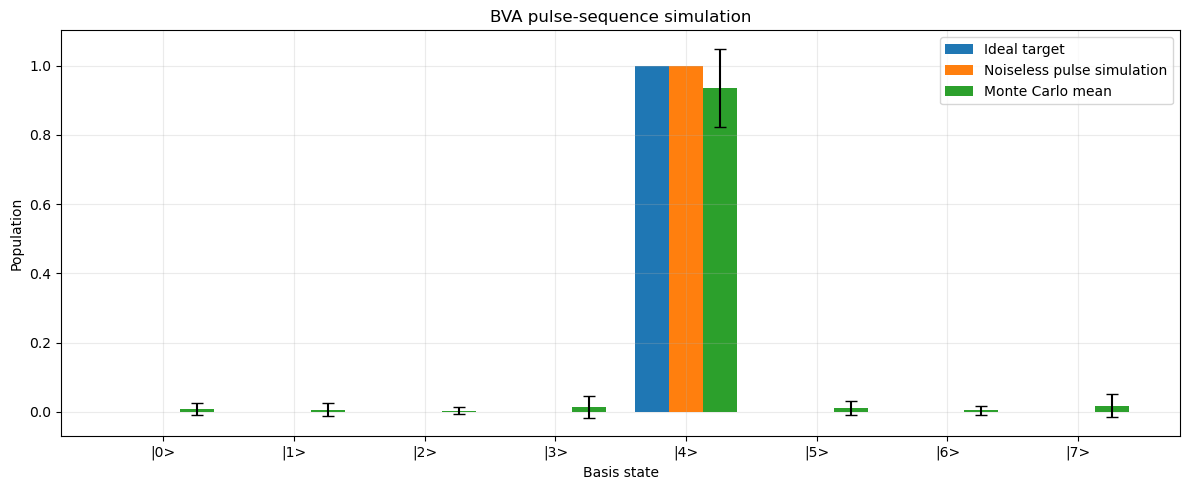

In [12]:
basis_labels = [f"|{index}>" for index in range(dim)]
x = np.arange(dim)
width = 0.26

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, ideal_populations, width=width, label="Ideal target")
ax.bar(x, noiseless_populations, width=width, label="Noiseless pulse simulation")
ax.bar(x + width, mean_noisy_populations, width=width, yerr=std_noisy_populations, capsize=4, label="Monte Carlo mean")

ax.set_xticks(x)
ax.set_xticklabels(basis_labels)
ax.set_xlabel("Basis state")
ax.set_ylabel("Population")
ax.set_title("BVA pulse-sequence simulation")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()
